In [1]:
from collections import Counter

import numpy as np
import polars as pl

from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
%matplotlib inline

In [2]:
# пути до файлов датасета
users_db = "../data/raw/VK-LSVD/metadata/users_metadata.parquet"
items_db = "../data/raw/VK-LSVD/metadata/items_metadata.parquet"
bhv_db = "../data/raw/VK-LSVD/subsamples/up0.001_ip0.001/train/week_*.parquet"

# Eexploratory Data Analysis

Одна из целевых моделей в работе, SASRec, для обучения использует скользящее окно в 2 недели. Эта часть данных о взаимодействиях позволит нам составить общее впечатление, не сильно погрешив против истины.

In [3]:
# грузим данные взаимодействий за первые 2 недели
df0 = pl.read_parquet("../data/raw/VK-LSVD/subsamples/up0.001_ip0.001/train/week_00.parquet")
df1 = pl.read_parquet("../data/raw/VK-LSVD/subsamples/up0.001_ip0.001/train/week_01.parquet")
df = pl.concat([df0, df1])

## Посмотрим на базовое распределение длин сессий

In [4]:
# в данном случае, будем называть сессией всю загруженную двухнедельную историю пользователя.
sessions = (
    df.group_by("user_id")
    .agg(
        pl.len().alias("count")
    )
)

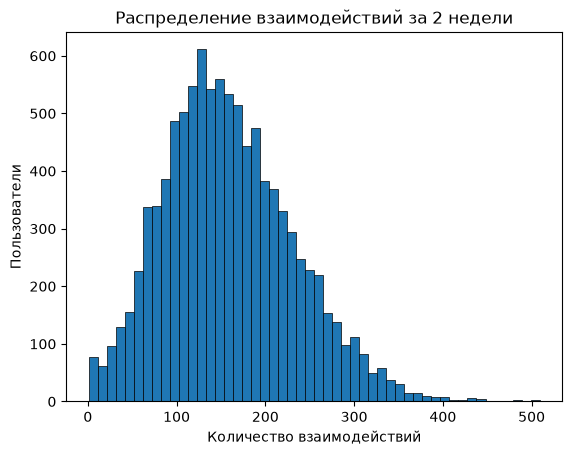

In [39]:
# Распределение взаимодействий за 2 недели
plt.hist(
    sessions['count'],
    bins=50,
    edgecolor='black',  # цвет обводки
    linewidth=.5,  # толщина обводки
)
plt.title("Распределение взаимодействий за 2 недели")
plt.xlabel("Количество взаимодействий")
plt.ylabel("Пользователи")
plt.show()

In [6]:
print(f"Девяностая процентиль равна: {sessions.select(pl.col("count").quantile(0.9).alias("q90")).item()}")

Девяностая процентиль равна: 258.0


Обрезка по девяностой процентили позволит нам обрезать историю только очень активных пользователей, при обучении SASRec. Возьмем значение max_len в настройках равным 258.

## Взглянем на распределение длин сессий

In [7]:
# считаем хиты среди загруженных взаимодействий, кого сколько раз показали.
items = (
    df.group_by("item_id")
    .agg(
        pl.len().alias("count")
    )
)

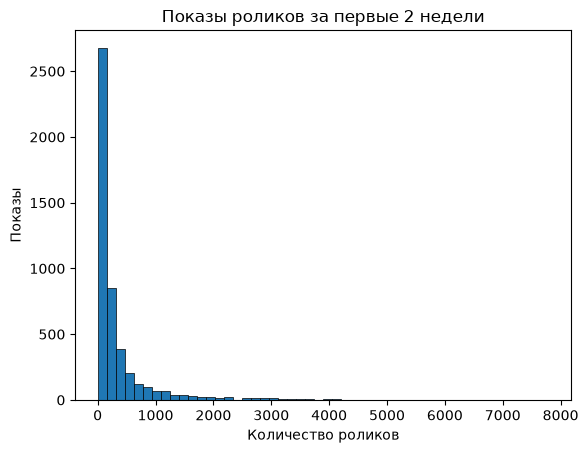

In [40]:
# Распределение
plt.hist(
    items["count"],
    bins=50,
    edgecolor='black',
    linewidth=.5,
)
plt.title("Показы роликов за первые 2 недели")
plt.xlabel("Количество роликов")
plt.ylabel("Показы")
plt.show()

Сильный отрыв в начале. Это может быть кликбейт от платформы, который почти никогда не досматривают. Попробуем понять.

In [9]:
# смотрим только на просмотры дольше 5 секунд или на которые пользователь отозвался реакцией
df_light = df.filter(
    (pl.col('timespent') >= 5) |
    (
            pl.col('like') | pl.col('dislike') | pl.col('share') | pl.col('bookmark') |
            pl.col('click_on_author') | pl.col('open_comments')
    )
)

In [10]:
# статистика по всем загруженным роликам
items.describe()

statistic,item_id,count
str,f64,f64
"""count""",4765.0,4765.0
"""null_count""",0.0,0.0
"""mean""",3.0439e8,331.313326
"""std""",1.7565e8,623.241257
"""min""",66761.0,1.0
"""25%""",1.5120488e8,31.0
"""50%""",3.05926781e8,119.0
"""75%""",4.5521157e8,326.0
"""max""",6.0803424e8,7793.0


In [11]:
# агрегируем данные для подсчета количества показов
items_light = (
    df_light.group_by("item_id")
    .agg(
        pl.len().alias("count")
    )
)

# статистика по значимым роликам, которые смотрели более 5 секунд, или по ним есть реакция пользователя
items_light.describe()

statistic,item_id,count
str,f64,f64
"""count""",4703.0,4703.0
"""null_count""",0.0,0.0
"""mean""",3.0425e8,200.154582
"""std""",1.7567e8,359.944335
"""min""",66761.0,1.0
"""25%""",1.51001887e8,22.0
"""50%""",3.05955112e8,79.0
"""75%""",4.54891665e8,217.0
"""max""",6.0803424e8,7189.0


Отрыв сократился, но не на столько значительно. Стоит рассмотреть повторы.

Получим ролики, которые просмотрели более 1000 раз за 2 недели.

In [12]:
# item_id текущих хитов
count = Counter()
for item in items.to_dicts():
    count[item['item_id']] += item['count']
hit1000 = [x for x in count.keys() if count[x]>1000]

# читаем данные о роликах
items_df = pl.read_parquet(items_db)

# агрегируем данные для получения данных об авторах хитов
hit_authors_df = items_df.filter(pl.col('item_id').is_in(hit1000)).group_by('author_id').agg(
    pl.len().alias("count")
).filter(pl.col('count') > 1)

len(items), len(hit1000), len(hit_authors_df)

(4765, 395, 61)

Всего было показано 4765 уникальных роликов, из них 395 были показаны более 1000 раз, и, среди авторов этих 395, 61 создал более 1 ролика.

**Получается (гипотеза):** пользователи отслеживают творчество отдельных авторов, информация о количестве роликов данного автора может способствовать продвижению остальных его роликов, чем больше у автора попыток, тем выше шансы создать нечто, интересное конечному пользователю.

## Рассмотрим Skipped vs Positive соотношение

In [13]:
total_pos = len(df_light)
total_neg = len(df) - total_pos
print(f"Позитивная активность: {total_pos}, Негативная: {total_neg}, %: {total_pos/len(df)*100:.2f}")

Позитивная активность: 941327, Негативная: 637381, %: 59.63


**Резюме:** У нас зачетных просмотров, дольше 5 секунд или имеют любую реакцию пользователя, немного больше половины, что позволяет для негативного самплинга выбирать не случайные записи, а те, которые пользователь явно отверг.

## Взглянем на повторы и разрывы

Есть два вопроса, которые могут представлять интерес:
- как часто пользователи смотрят по нескольку раз один и тот же ролик (интерес могут представлять сами повторы, вперемешку с другими роликами, и грубая накрутка, когда ролики смотрят несколько раз подряд)?
- пользователь некоторое время побыл на платформе, а потом пропал, не навсегда пропал, а на какое - то время, не важна причина, отпуск, болезнь, занятость, телефон потерял, важен сам факт бездействия, и нужно понять, как часто это происходит, и нужна ли отдельная отработка таких кейсов.

In [14]:
# смотрим повторы подряд, сразу на всем датасете
df_meta = pl.read_parquet(bhv_db)
df_with_lag = df_meta.with_columns([
    pl.col('item_id').shift(1).over('user_id').alias('prev_item')
])

# Считаем долю повторов подряд
repeat_immediate = (
    df_with_lag
    .filter(pl.col('item_id') == pl.col('prev_item'))
    .shape[0] / df_meta.shape[0]
)

print(f"Доля повторов подряд: {repeat_immediate:.2%}")

Доля повторов подряд: 0.00%


In [15]:
# повторы в пределах сессии (вперемешку)
user_sequences = (
    df.group_by('user_id')
    .agg(pl.col('item_id').alias('items'))
)

# считаем, сколько уникальных роликов vs общее количество просмотров
user_repeat_stats = user_sequences.with_columns([
    pl.col('items').list.len().alias('total_views'),
    pl.col('items').list.unique().list.len().alias('unique_views')
]).with_columns([
    (1 - (pl.col('unique_views') / pl.col('total_views'))).alias('repeat_rate')
])

# средняя доля повторных просмотров
avg_repeat_rate = user_repeat_stats['repeat_rate'].mean()
print(f"Средняя доля повторных просмотров на пользователя: {avg_repeat_rate:.2%}")

Средняя доля повторных просмотров на пользователя: 0.00%


Маркеров времени у нас нет, но разрыв в неделях, если найдется, мы можем посчитать.

Для реально большого датасета придется брать последовательно, неделю за неделей, и выделять пользователей, которые пропали или появились в логе активностей, потом все это сравнивать. Попробуем уложиться в память компьютера, и если возникнут сложности, будем с ними бороться постепенно.

In [16]:
# Загружаем все недели
df0 = pl.read_parquet("../data/raw/VK-LSVD/subsamples/up0.001_ip0.001/train/week_00.parquet")
df0 = df0.with_columns(week_num=pl.lit(0))

for week_num in range(1, 25):
    dfx = pl.read_parquet(f"../data/raw/VK-LSVD/subsamples/up0.001_ip0.001/train/week_{week_num:02}.parquet")
    dfx = dfx.with_columns(week_num=pl.lit(week_num))
    df0 = pl.concat([df0, dfx])

# Сортируем по пользователю и номеру недели (внутри недели порядок уже хронологический)
df_sorted = df0.sort(['user_id', 'week_num'])

# Добавляем лаг: предыдущая неделя для каждого пользователя
df_with_lag = df_sorted.with_columns([
    pl.col('week_num').shift(1).over('user_id').alias('prev_week_num')
])

# Разрыв = разница между текущей и предыдущей неделей > 1
gaps = df_with_lag.filter(
    (pl.col('prev_week_num').is_not_null()) &
    (pl.col('week_num') - pl.col('prev_week_num') > 1)
)
gaps.select(['user_id', 'item_id', 'prev_week_num', 'week_num']).with_columns(week_diff=pl.col('week_num') - pl.col('prev_week_num'))

user_id,item_id,prev_week_num,week_num,week_diff
u32,u32,i32,i32,i32
2823202,123139247,9,11,2
5231145,51732461,7,9,2
7885997,296114580,2,4,2
9826547,12877705,5,7,2
10516693,407537409,1,3,2
…,…,…,…,…
501538544,551569531,1,3,2
501538544,101868593,4,6,2
502206970,370900860,0,2,2


In [17]:
gaps.shape[0], gaps['user_id'].n_unique()

(196, 184)

In [18]:
# Распределение разрывов по неделям
gap_distribution = (
    gaps
    .with_columns((pl.col('week_num') - pl.col('prev_week_num')).alias('gap_weeks'))
    .group_by('gap_weeks')
    .agg(pl.len().alias('count'))
    .sort('gap_weeks')
)

print(gap_distribution)

# Доля переходов, которые являются разрывами
total_transitions = df_with_lag.filter(pl.col('prev_week_num').is_not_null()).shape[0]
gap_ratio = gaps.shape[0] / total_transitions
print(f"Доля переходов с разрывами > 1 недели: {gap_ratio:.2%}")

shape: (4, 2)
┌───────────┬───────┐
│ gap_weeks ┆ count │
│ ---       ┆ ---   │
│ i32       ┆ u32   │
╞═══════════╪═══════╡
│ 2         ┆ 159   │
│ 3         ┆ 27    │
│ 4         ┆ 8     │
│ 5         ┆ 2     │
└───────────┴───────┘
Доля переходов с разрывами > 1 недели: 0.00%


У нас в датасете 10_000_000 пользователей, по истории взаимодействия которых мы имеем 196 переходов типа "разрыв" для 184 пользователей.

**Резюме:** несмотря на то, что разрывы присутствуют, их количество незначительно, и, на данном этапе может быть проигнорировано.

## Посмотрим на активность по неделям

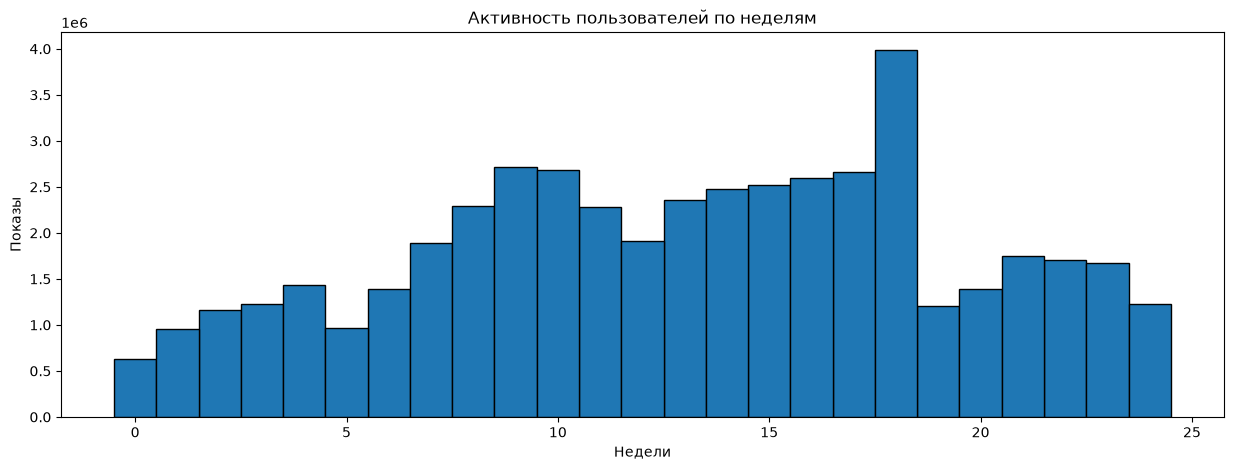

In [37]:
activity = (
    df_sorted.group_by("week_num")
    .agg(
        pl.len().alias("count")
    )
)

# распределение
plt.figure(figsize=(15, 5))
plt.bar(
    activity["week_num"].to_list(),
    activity["count"].to_list(),
    width=1,  # Ширина столбцов в днях (можно настроить под себя)
    edgecolor="black",
    linewidth=1,
)
plt.title("Активность пользователей по неделям")
plt.xlabel("Недели")
plt.ylabel("Показы")
plt.show()

**Получается (гипотеза):** на графике наблюдаются временные паттерны и тренд, который устойчиво растет 18 недель, стоит взять более подробный датасет и попробовать арсенал time-series моделей.

## Посмотрим на то, как группируются пользователи по роликам, которые они смотрят

In [20]:
df = pl.read_parquet(bhv_db)

# берём топ-N самых популярных роликов (чтобы не раздувать размерность)
top_items = (
    df.group_by('item_id')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .head(1000)
)['item_id'].to_list()

# фильтруем транзакции, оставляя только топ-1000 роликов
df_filtered = df.filter(pl.col('item_id').is_in(top_items))

# строим матрицу пользователь-ролик (бинарную: смотрел/не смотрел)
user_item_matrix = (
    df_filtered
    .group_by('user_id')
    .agg(pl.col('item_id').unique().alias('items'))
)

# создаём бинарный вектор для каждого пользователя
def make_binary_vector(items, top_items):
    vec = np.zeros(len(top_items))
    for item in items:
        if item in top_items:
            vec[top_items.index(item)] = 1
    return vec

# применяем к каждому пользователю, но для отобранного набора приемлемо
user_vectors = []
for row in user_item_matrix.rows():
    user_vectors.append(make_binary_vector(row[1], top_items))

user_vectors = np.array(user_vectors)

svd = TruncatedSVD(n_components=50, random_state=42)
user_vectors_reduced = svd.fit_transform(user_vectors)

user_vectors_norm = normalize(user_vectors_reduced, norm='l2')

Если пользователи кластеризуются, то поищем их оптимальное количество.

In [21]:
best_k = 3
best_score = 0.0

for k in range(3, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(user_vectors_norm)
    score = silhouette_score(user_vectors_norm, clusters)
    if score > best_score:
        best_k = k
        best_score = score

Строим кластеры и смотрим на статистику полученного.

In [22]:
# кластеризуем
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(user_vectors_norm)

# смотрим на размеры кластеров
unique, counts = np.unique(clusters, return_counts=True)
print("Размеры кластеров:", dict(zip(unique, counts)))

# смотрим на среднюю длину истории в каждом кластере
avg_history_len = []
for cluster_id in range(best_k):
    users_in_cluster = user_item_matrix.filter(clusters == cluster_id).select('user_id')
    lens = df_filtered.filter(pl.col('user_id').is_in(users_in_cluster['user_id'].to_list())).group_by('user_id').agg(pl.len())
    avg_history_len.append(lens['len'].mean())

print("Средняя длина истории по кластерам:", avg_history_len)

Размеры кластеров: {np.int32(0): np.int64(2612), np.int32(1): np.int64(5423), np.int32(2): np.int64(1965)}
Средняя длина истории по кластерам: [605.6902756508423, 712.6828323806011, 549.3847328244275]


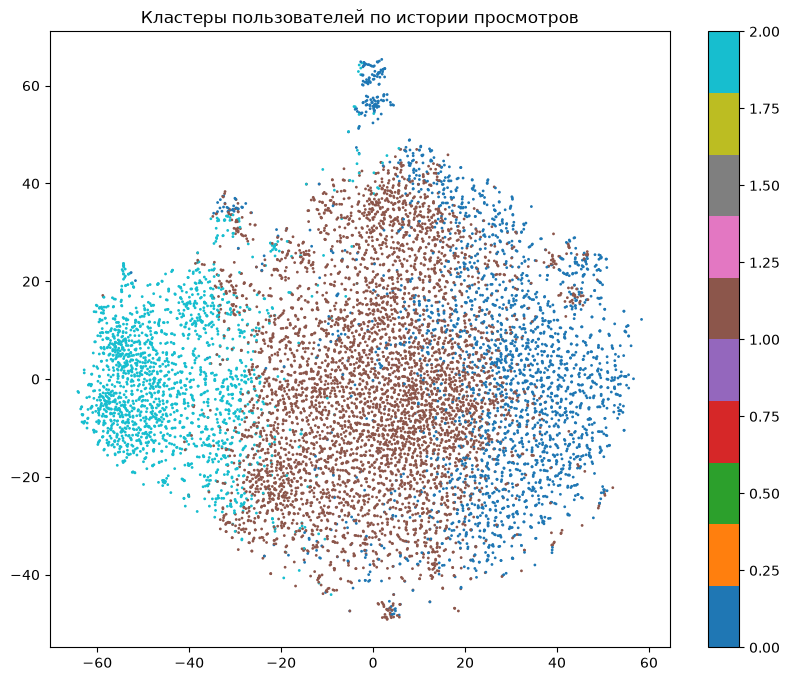

In [23]:
# визуализируем
tsne = TSNE(n_components=2, random_state=42)
vectors_2d = tsne.fit_transform(user_vectors_norm)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=clusters, cmap='tab10', s=1)
plt.title('Кластеры пользователей по истории просмотров')
plt.colorbar(scatter)
plt.show()

На взгляд, кластеры хорошо разделены.

In [24]:
user_clusters = []

# для каждого кластера найти топ-5 роликов, которые смотрят пользователи из этого кластера
for cluster_id in range(3):
    users = user_item_matrix.filter(clusters == cluster_id).select(['user_id'])['user_id'].to_list()
    for uid in users:
        user_clusters.append({'user_id': uid, 'cluster_id': cluster_id})
    top_items_in_cluster = (
        df.filter(pl.col('user_id').is_in(users))
        .group_by('item_id')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
        .head(5)
    )
    print(f"Кластер {cluster_id}: {top_items_in_cluster['item_id'].to_list()}")

Кластер 0: [581335391, 510684644, 433004104, 469137962, 37051147]
Кластер 1: [510684644, 433004104, 17623587, 46267661, 342549546]
Кластер 2: [269477083, 17623587, 302940690, 2754978, 416257601]


Предпочтения по кластерам различаются, что дает основание рассмотреть включение этого признака в данные модели.

**Получается (гипотеза):** пользователи отделимы друг от друга, по своим предпочтениям, как минимум, на 3 группы, стоит их гендерное, возрастное и прочее распределение изучить отдельно.

### Оценим распределение возрастов по найденным кластерам.

In [25]:
# загружаем данные пользователей (с демографией)
users_meta = pl.read_parquet("../data/raw/VK-LSVD/metadata/users_metadata.parquet")

user_clusters_ = pl.from_dicts(user_clusters)
# присоединяем демографию к кластерам
users_with_cluster = users_meta.join(user_clusters_, on='user_id')

# смотрим распределение возрастов по кластерам
age_distribution = (
    users_with_cluster
    .group_by('cluster_id')
    .agg([
        pl.col('age').mean().alias('avg_age'),
        pl.col('age').std().alias('std_age'),
        pl.col('age').quantile(0.25).alias('q25_age'),
        pl.col('age').quantile(0.50).alias('q50_age'),
        pl.col('age').quantile(0.75).alias('q75_age'),
    ])
)

print(age_distribution)

shape: (3, 6)
┌────────────┬───────────┬───────────┬─────────┬─────────┬─────────┐
│ cluster_id ┆ avg_age   ┆ std_age   ┆ q25_age ┆ q50_age ┆ q75_age │
│ ---        ┆ ---       ┆ ---       ┆ ---     ┆ ---     ┆ ---     │
│ i64        ┆ f64       ┆ f64       ┆ f64     ┆ f64     ┆ f64     │
╞════════════╪═══════════╪═══════════╪═════════╪═════════╪═════════╡
│ 0          ┆ 36.535222 ┆ 10.230469 ┆ 29.0    ┆ 36.0    ┆ 43.0    │
│ 1          ┆ 34.425779 ┆ 10.807373 ┆ 26.0    ┆ 33.0    ┆ 40.0    │
│ 2          ┆ 32.15827  ┆ 11.738577 ┆ 22.0    ┆ 30.0    ┆ 39.0    │
└────────────┴───────────┴───────────┴─────────┴─────────┴─────────┘


**Получается (гипотеза):** возраст коррелирует с полученными кластерами, и может быть использован для уточнения рекомендаций для совсем "холодного" пользователя.

### Смотрим на распределение регионов по найденым кластерам

In [31]:
# смотрим топ-регионы по кластерам
top_regions = (
    users_with_cluster
    .group_by(['cluster_id', 'geo'])
    .agg(pl.len().alias('count'))
    .sort(['cluster_id', 'count'], descending=[False, True])
    .group_by('cluster_id')
    .agg(pl.col('geo').head(19).alias('top_regions'))
)

top_regions['top_regions'].to_list()

[[79, 78, 76, 77, 71, 74, 70, 72, 65, 73, 68, 61, 69, 62, 66, 75, 59, 42, 39],
 [79, 78, 77, 76, 74, 75, 71, 73, 72, 67, 61, 70, 62, 69, 68, 65, 66, 57, 63],
 [79, 78, 76, 77, 74, 75, 65, 72, 67, 70, 71, 62, 66, 73, 68, 69, 61, 63, 59]]

**Резюме:** регион с предпочтениями ни как не коррелирует.

## Попробуем оценить похожесть авторов

Хотя авторы датасета и постарались убрать все коллаборативные сигналы, один у нас все таки есть: пользователи, которые его смотрят. Попробуем оценить схожесть авторов по схожести предпочтений пользователей, которые их смотрят.

In [32]:
items_meta = pl.read_parquet(items_db)
ia = items_meta.select(["item_id", "author_id", "duration"])
dfx = df.join(ia, on='item_id', how='inner')

user_id,item_id,place,platform,agent,timespent,like,dislike,share,bookmark,click_on_author,open_comments,author_id,duration
u32,u32,u8,u8,u8,u8,bool,bool,bool,bool,bool,bool,u32,u8
141827770,160593626,1,1,1,56,false,false,false,false,false,false,250935,83
468779351,327484273,1,0,0,1,false,false,false,false,false,false,1178975,12
494341617,402842289,1,0,0,11,false,false,false,false,false,false,1238991,11
453833313,102672169,0,0,0,45,false,false,false,false,false,false,1040966,45
154047442,139795075,1,0,0,39,false,false,false,false,false,false,361464,14
…,…,…,…,…,…,…,…,…,…,…,…,…,…
392573923,182950170,1,0,0,2,false,false,false,false,false,false,1038695,23
378918593,355047751,1,1,1,4,false,false,false,false,false,false,1041951,27
204650228,293496622,1,1,1,47,false,false,false,false,false,false,294840,51


In [33]:
# группируем по пользователю: собираем уникальных авторов, которых он смотрел
user_authors = (
    dfx
    .group_by('user_id')
    .agg(pl.col('author_id').unique().alias('authors'))
)

# строим бинарную матрицу пользователь-автор (разреженную)
from sklearn.feature_extraction.text import CountVectorizer

# превращаем список авторов в строку для CountVectorizer
user_authors_str = user_authors.with_columns(
    pl.col('authors')
    .list.eval(pl.element().cast(pl.Utf8))  # каждый элемент → строка
    .list.join(' ')                          # соединяем в одну строку
    .alias('authors_str')
).select(['user_id', 'authors_str'])


vectorizer = CountVectorizer(token_pattern=r'\d+', binary=True)
author_matrix = vectorizer.fit_transform(user_authors_str['authors_str'])

author_similarity = cosine_similarity(author_matrix.T)  # [N_authors, N_authors]

# для каждого автора находим топ-5 похожих
author_ids = vectorizer.get_feature_names_out()
for idx, author in enumerate(author_ids[:10]):  # первые 10 авторов
    similar_idx = author_similarity[idx].argsort()[-6:-1][::-1]
    similar_authors = [author_ids[i] for i in similar_idx]
    print(f"Автор {author} похож на: {similar_authors}")

Автор 1000301 похож на: ['414462', '832228', '1235552', '44054', '1184453']
Автор 1000494 похож на: ['1101555', '1011002', '456213', '1223910', '983687']
Автор 1000527 похож на: ['272950', '1092495', '231296', '276006', '360266']
Автор 1000723 похож на: ['304004', '91555', '214153', '214155', '810374']
Автор 1001233 похож на: ['508465', '1229155', '256863', '305287', '326655']
Автор 1001456 похож на: ['309919', '268967', '103011', '821417', '618154']
Автор 1001565 похож на: ['596068', '396893', '265710', '1237459', '432679']
Автор 1001641 похож на: ['1173524', '1159033', '316687', '302420', '331364']
Автор 1002038 похож на: ['332414', '1225617', '1211561', '316684', '1191829']
Автор 1002068 похож на: ['249564', '1265943', '256863', '1173524', '326658']


In [34]:
# проверка: симметричность на уровне матрицы
is_symmetric = np.allclose(author_similarity, author_similarity.T, atol=1e-6)
print(f"Матрица симметрична: {is_symmetric}")

# проверка: симметричность на уровне топ-5 (более строгая)
# для каждого автора A проверяем: если B в топ-5 для A, то A в топ-5 для B?

author_ids = vectorizer.get_feature_names_out().astype(int)
author_id_to_idx = {int(aid): idx for idx, aid in enumerate(author_ids)}

def check_topk_symmetry(similarity_matrix, author_ids, k=5):
    """
    Проверяет, симметричны ли топ-k соседей.
    Возвращает долю пар, для которых A→B и B→A совпадают.
    """
    n = len(author_ids)
    symmetric_count = 0
    total_count = 0

    for i in range(n):
        # Топ-k для автора i (исключая себя)
        top_k_i = set(np.argsort(similarity_matrix[i])[-k-1:-1])

        for j in top_k_i:
            # Топ-k для автора j (исключая себя)
            top_k_j = set(np.argsort(similarity_matrix[j])[-k-1:-1])

            if i in top_k_j:
                symmetric_count += 1
            total_count += 1

    return symmetric_count / total_count if total_count > 0 else 0

symmetry_score = check_topk_symmetry(author_similarity, author_ids, k=5)
print(f"Доля симметричных пар в топ-5: {symmetry_score:.2%}")

Матрица симметрична: True
Доля симметричных пар в топ-5: 5.76%


In [35]:
# для случайной тройки (A, B, C), где B в топ-5 для A, а C в топ-5 для B
# проверяем, входит ли C в топ-20 для A

transitive_count = 0
total_count = 0

for i in range(100):  # проверяем 100 случайных авторов
    top_k_i = np.argsort(author_similarity[i])[-6:-1]
    for j in top_k_i:
        top_k_j = np.argsort(author_similarity[j])[-6:-1]
        for k in top_k_j:
            if k != i:
                top_20_i = np.argsort(author_similarity[i])[-21:-1]
                if k in top_20_i:
                    transitive_count += 1
                total_count += 1

print(f"Транзитивность (A→B→C ⇒ A→C в топ-20): {transitive_count/total_count:.2%}")

Транзитивность (A→B→C ⇒ A→C в топ-20): 55.30%


Доля симметричных пар в топ-5 может быть низкой из за разницы размеров аудитории каждого из них. Возможно, стоит подумать, как учесть этот фактор.

Отношение симметрично и транзитивно.

**Получается (гипотеза):** для пользователя, подписанного на автора $A$, можно поискать похожего на него автора $B$ и рассмотреть его ролики в качестве рекомендации.

# Итог

Подведем итог.

Просто полезные наблюдения:
- в настройках SASRec модели укажем max_len = 258
- информация о количестве роликов данного автора может способствовать продвижению остальных его роликов
- на графике наблюдаются временные паттерны и тренд, который устойчиво растет 18 недель, стоит взять более подробный датасет и попробовать арсенал time-series моделей

Идеи, которые подтверждаются:
- пользователи отслеживают творчество отдельных авторов
- чем больше у автора попыток, тем выше шансы создать нечто, интересное конечному пользователю
- пользователи отделимы друг от друга, по своим предпочтениям, как минимум, на 3
- возраст коррелирует с полученными кластерами, и может быть использован для уточнения рекомендаций для совсем "холодного" пользователя
- для пользователя, подписанного на автора A, можно поискать похожего на него автора B и рассмотреть его ролики в качестве рекомендации

Идеи, которые не подтвердились:
- несмотря на то, что разрывы в истории присутствуют, их количество незначительно и может быть проигнорировано
- регион с предпочтениями ни как не коррелирует